Logistic Regression

In [9]:
import ast
import pickle

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [10]:
raw_df = pd.read_csv('dblp-v10.csv', engine='python', on_bad_lines='skip')

print('Original rows:', len(raw_df))
print('Original duplicate rows:', raw_df.duplicated().sum())
print('Original missing values per column:')
print(raw_df.isna().sum())

raw_df.head()

Original rows: 11350
Original duplicate rows: 0
Original missing values per column:
abstract      422
authors         0
n_citation      0
references    286
title           0
venue         996
year            0
id              0
dtype: int64


,abstract,authors,n_citation,references,title,venue,year,id
0,"In this paper, a robust 3D triangular mesh wat...","['S. Ben Jabra', 'Ezzeddine Zagrouba']",50,"['09cb2d7d-47d1-4a85-bfe5-faa8221e644b', '10aa...",A new approach of 3D watermarking based on ima...,international symposium on computers and commu...,2008,4ab3735c-80f1-472d-b953-fa0557fed28b
1,We studied an autoassociative neural network w...,"['Joaquín J. Torres', 'Jesús M. Cortés', 'Joaq...",50,"['4017c9d2-9845-4ad2-ad5b-ba65523727c5', 'b118...",Attractor neural networks with activity-depend...,Neurocomputing,2007,4ab39729-af77-46f7-a662-16984fb9c1db
2,It is well-known that Sturmian sequences are t...,"['Genevi eve Paquin', 'Laurent Vuillon']",50,"['1c655ee2-067d-4bc4-b8cc-bc779e9a7f10', '2e4e...",A characterization of balanced episturmian seq...,Electronic Journal of Combinatorics,2007,4ab3a4cf-1d96-4ce5-ab6f-b3e19fc260de
3,One of the fundamental challenges of recognizi...,"['Yaser Sheikh', 'Mumtaz Sheikh', 'Mubarak Shah']",221,"['056116c1-9e7a-4f9b-a918-44eb199e67d6', '05ac...",Exploring the space of a human action,international conference on computer vision,2005,4ab3a98c-3620-47ec-b578-884ecf4a6206
4,This paper generalizes previous optimal upper ...,"['Efraim Laksman', 'Håkan Lennerstad', 'Magnus...",0,"['01a765b8-0cb3-495c-996f-29c36756b435', '5dbc...",Generalized upper bounds on the minimum distan...,Ima Journal of Mathematical Control and Inform...,2015,4ab3b585-82b4-4207-91dd-b6bce7e27c4e


In [11]:
def count_list_items(value):
    if pd.isna(value):
        return 0

    text = str(value).strip()
    if text in ('', '[]', 'nan', 'None'):
        return 0

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, set, dict)):
            return len(parsed)
    except (ValueError, SyntaxError):
        pass

    cleaned = text.strip('[]')
    if not cleaned:
        return 0

    return len([item for item in cleaned.split(',') if item.strip()])

clean_df = raw_df.drop_duplicates().copy()
text_columns = ['abstract', 'authors', 'references', 'title', 'venue']
clean_df[text_columns] = clean_df[text_columns].fillna('')
clean_df['year'] = pd.to_numeric(clean_df['year'], errors='coerce')
clean_df['n_citation'] = pd.to_numeric(clean_df['n_citation'], errors='coerce')
clean_df = clean_df.dropna(subset=['year', 'n_citation']).copy()
clean_df['year'] = clean_df['year'].astype(int)
clean_df['reference_count'] = clean_df['references'].apply(count_list_items)
clean_df['author_count'] = clean_df['authors'].apply(count_list_items)
clean_df['title_length'] = clean_df['title'].str.len()
clean_df['abstract_length'] = clean_df['abstract'].str.len()
clean_df['venue_length'] = clean_df['venue'].str.len()
clean_df['title_word_count'] = clean_df['title'].str.split().str.len().fillna(0).astype(int)
clean_df['abstract_word_count'] = clean_df['abstract'].str.split().str.len().fillna(0).astype(int)
clean_df['high_impact'] = (clean_df['n_citation'] > clean_df['n_citation'].median()).astype(int)

print('Cleaned rows:', len(clean_df))
print('Cleaned duplicate rows:', clean_df.duplicated().sum())
print('Cleaned missing values per column:')
print(clean_df.isna().sum())
print('Class balance:')
print(clean_df['high_impact'].value_counts(normalize=True).sort_index())

assert clean_df.isna().sum().sum() == 0
assert clean_df.duplicated().sum() == 0

clean_df.head()

Cleaned rows: 11350
Cleaned duplicate rows: 0
Cleaned missing values per column:
abstract               0
authors                0
n_citation             0
references             0
title                  0
venue                  0
year                   0
id                     0
reference_count        0
author_count           0
title_length           0
abstract_length        0
venue_length           0
title_word_count       0
abstract_word_count    0
high_impact            0
dtype: int64
Class balance:
high_impact
0    0.82467
1    0.17533
Name: proportion, dtype: float64


,abstract,authors,n_citation,references,title,venue,year,id,reference_count,author_count,title_length,abstract_length,venue_length,title_word_count,abstract_word_count,high_impact
0,"In this paper, a robust 3D triangular mesh wat...","['S. Ben Jabra', 'Ezzeddine Zagrouba']",50,"['09cb2d7d-47d1-4a85-bfe5-faa8221e644b', '10aa...",A new approach of 3D watermarking based on ima...,international symposium on computers and commu...,2008,4ab3735c-80f1-472d-b953-fa0557fed28b,7,2,61,511,55,10,73,0
1,We studied an autoassociative neural network w...,"['Joaquín J. Torres', 'Jesús M. Cortés', 'Joaq...",50,"['4017c9d2-9845-4ad2-ad5b-ba65523727c5', 'b118...",Attractor neural networks with activity-depend...,Neurocomputing,2007,4ab39729-af77-46f7-a662-16984fb9c1db,3,4,93,1021,14,11,143,0
2,It is well-known that Sturmian sequences are t...,"['Genevi eve Paquin', 'Laurent Vuillon']",50,"['1c655ee2-067d-4bc4-b8cc-bc779e9a7f10', '2e4e...",A characterization of balanced episturmian seq...,Electronic Journal of Combinatorics,2007,4ab3a4cf-1d96-4ce5-ab6f-b3e19fc260de,7,2,52,711,35,6,103,0
3,One of the fundamental challenges of recognizi...,"['Yaser Sheikh', 'Mumtaz Sheikh', 'Mubarak Shah']",221,"['056116c1-9e7a-4f9b-a918-44eb199e67d6', '05ac...",Exploring the space of a human action,international conference on computer vision,2005,4ab3a98c-3620-47ec-b578-884ecf4a6206,10,3,37,1019,43,7,159,1
4,This paper generalizes previous optimal upper ...,"['Efraim Laksman', 'Håkan Lennerstad', 'Magnus...",0,"['01a765b8-0cb3-495c-996f-29c36756b435', '5dbc...",Generalized upper bounds on the minimum distan...,Ima Journal of Mathematical Control and Inform...,2015,4ab3b585-82b4-4207-91dd-b6bce7e27c4e,9,3,67,201,51,11,31,0


The dataset is now cleaned with duplicate rows removed and text nulls filled so the working dataframe has no missing values.

The target column `high_impact` is binary, so this is a logistic regression problem. The extra numeric features give the model more signal than year and reference count alone.

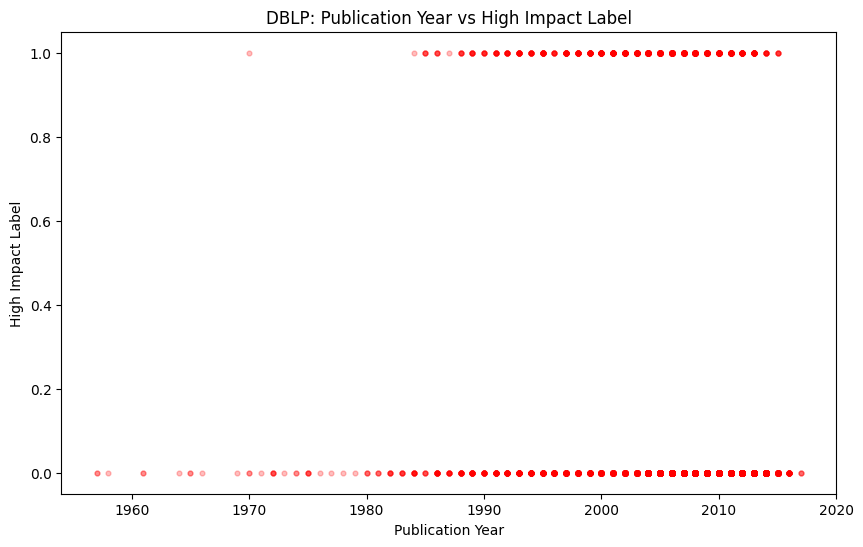

In [12]:
plot_df = clean_df.sample(n=min(5000, len(clean_df)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(plot_df['year'], plot_df['high_impact'], alpha=0.25, color='red', s=12)
plt.xlabel('Publication Year')
plt.ylabel('High Impact Label')
plt.title('DBLP: Publication Year vs High Impact Label')
plt.show()

In [13]:
feature_sets = {
    'basic': ['year', 'reference_count'],
    'engineered': [
        'year',
        'reference_count',
        'author_count',
        'title_length',
        'abstract_length',
        'venue_length',
        'title_word_count',
        'abstract_word_count',
    ],
}

all_feature_columns = [
    'year',
    'reference_count',
    'author_count',
    'title_length',
    'abstract_length',
    'venue_length',
    'title_word_count',
    'abstract_word_count',
 ]

X = clean_df[all_feature_columns]
y = clean_df['high_impact']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test.head()

,year,reference_count,author_count,title_length,abstract_length,venue_length,title_word_count,abstract_word_count
2819,2004,8,3,75,1176,39,11,183
4721,1997,5,2,47,0,68,8,0
11240,2011,1,5,77,773,0,11,119
4159,2004,5,2,29,736,34,4,104
8784,2009,4,2,64,583,56,8,84


In [14]:
search_frame = X_train_full.copy()
search_frame['high_impact'] = y_train_full.values

search_frame = search_frame.sample(n=min(50000, len(search_frame)), random_state=42)

search_train, search_val = train_test_split(
    search_frame,
    test_size=0.25,
    random_state=42,
    stratify=search_frame['high_impact']
)

candidate_C = [0.1, 1.0, 5.0]
thresholds = np.round(np.arange(0.30, 0.71, 0.05), 2)
results = []

for feature_name, feature_columns in feature_sets.items():
    for C in candidate_C:
        candidate_model = Pipeline([
            ('scaler', StandardScaler()),
            ('logreg', LogisticRegression(max_iter=2000, C=C))
        ])
        candidate_model.fit(search_train[feature_columns], search_train['high_impact'])
        validation_probabilities = candidate_model.predict_proba(search_val[feature_columns])[:, 1]

        for threshold in thresholds:
            validation_predictions = (validation_probabilities >= threshold).astype(int)
            validation_accuracy = accuracy_score(search_val['high_impact'], validation_predictions)
            results.append({
                'feature_set': feature_name,
                'C': C,
                'threshold': float(threshold),
                'validation_accuracy': validation_accuracy,
            })

results_df = pd.DataFrame(results).sort_values('validation_accuracy', ascending=False)
print(results_df.head(10).to_string(index=False))

best_row = results_df.iloc[0]
best_feature_columns = feature_sets[best_row['feature_set']]
best_c = float(best_row['C'])
best_threshold = float(best_row['threshold'])

print('Best feature set:', best_row['feature_set'])
print('Best C:', best_c)
print('Best threshold:', best_threshold)

best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000, C=best_c))
])
best_model.fit(X_train_full[best_feature_columns], y_train_full)

feature_set   C  threshold  validation_accuracy
      basic 0.1       0.50             0.823789
      basic 0.1       0.55             0.823789
      basic 1.0       0.55             0.823789
      basic 5.0       0.55             0.823789
 engineered 0.1       0.55             0.823348
      basic 0.1       0.70             0.823348
 engineered 0.1       0.65             0.823348
      basic 1.0       0.70             0.822907
 engineered 0.1       0.70             0.822907
      basic 5.0       0.60             0.822907
Best feature set: basic
Best C: 0.1
Best threshold: 0.5


Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(C=0.1, max_iter=2000))])

Best feature columns: ['year', 'reference_count']
Best threshold: 0.5
Accuracy: 0.8176211453744493
Model score at default 0.5 threshold: 0.8176211453744493
Classification report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      1872
           1       0.21      0.02      0.03       398

    accuracy                           0.82      2270
   macro avg       0.52      0.50      0.46      2270
weighted avg       0.72      0.82      0.75      2270



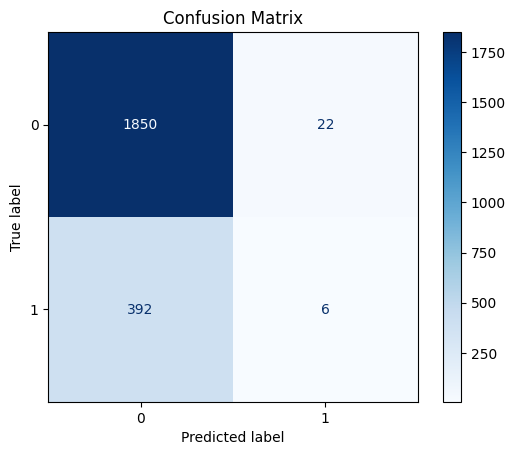

In [15]:
test_probabilities = best_model.predict_proba(X_test[best_feature_columns])[:, 1]
y_predicted = (test_probabilities >= best_threshold).astype(int)

print('Best feature columns:', best_feature_columns)
print('Best threshold:', best_threshold)
print('Accuracy:', accuracy_score(y_test, y_predicted))
print('Model score at default 0.5 threshold:', best_model.score(X_test[best_feature_columns], y_test))
print('Classification report:')
print(classification_report(y_test, y_predicted))

cm = confusion_matrix(y_test, y_predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

**best_model.named_steps['logreg'].coef_ indicates the learned weights for the selected logistic regression features**

In [16]:
best_model.named_steps['logreg'].coef_

array([[-0.47251858,  0.55886227]])

**best_model.named_steps['logreg'].intercept_ indicates the bias term learned by the selected logistic regression model**

In [17]:
best_model.named_steps['logreg'].intercept_

array([-1.65379474])

In [18]:
sample_input = pd.DataFrame({
    'year': [2015],
    'reference_count': [15],
    'author_count': [4],
    'title_length': [55],
    'abstract_length': [850],
    'venue_length': [42],
    'title_word_count': [8],
    'abstract_word_count': [120],
})

sample_features = sample_input[best_feature_columns]
sample_probability = best_model.predict_proba(sample_features)[:, 1][0]
sample_prediction = int(sample_probability >= best_threshold)

print('Sample prediction:', sample_prediction)
print('Sample prediction probability:', sample_probability)

with open('model_pickle', 'wb') as file:
    pickle.dump(best_model, file)

with open('model_pickle', 'rb') as file:
    loaded_pickle_model = pickle.load(file)

print('Pickle loaded coefficients:', loaded_pickle_model.named_steps['logreg'].coef_)
print('Pickle loaded intercept:', loaded_pickle_model.named_steps['logreg'].intercept_)
print('Pickle loaded prediction:', int(loaded_pickle_model.predict_proba(sample_features)[:, 1][0] >= best_threshold))

joblib.dump(best_model, 'model_joblib')
loaded_joblib_model = joblib.load('model_joblib')

print('Joblib loaded coefficients:', loaded_joblib_model.named_steps['logreg'].coef_)
print('Joblib loaded intercept:', loaded_joblib_model.named_steps['logreg'].intercept_)
print('Joblib loaded prediction:', int(loaded_joblib_model.predict_proba(sample_features)[:, 1][0] >= best_threshold))

Sample prediction: 0
Sample prediction probability: 0.12984393390579405
Pickle loaded coefficients: [[-0.47251858  0.55886227]]
Pickle loaded intercept: [-1.65379474]
Pickle loaded prediction: 0
Joblib loaded coefficients: [[-0.47251858  0.55886227]]
Joblib loaded intercept: [-1.65379474]
Joblib loaded prediction: 0
